<a href="https://colab.research.google.com/github/Clover130/u8229609-EMSC2010-W10-L1/blob/main/EMSC2010_W10_L1_NB3_u8229609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-L1-NB3

In this notebook we'll create a sinusoidal signal and add noise to it.

We'll then see if we can remove the noise and recover the original signal using a moving average approach.

Import the libraries we'll need.

In [1]:
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library

A moving average can be calculated efficiently using an approach called *convolution*.

The function below will calculate a ```w``` point moving average (where you define ```w```) using a single line of code. Note that ```w``` must be a positive whole number.

In [2]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

Now we'll create a sine wave and add some random numbers to it in order to represent noise. We'll be talking more about sine waves in our next session.

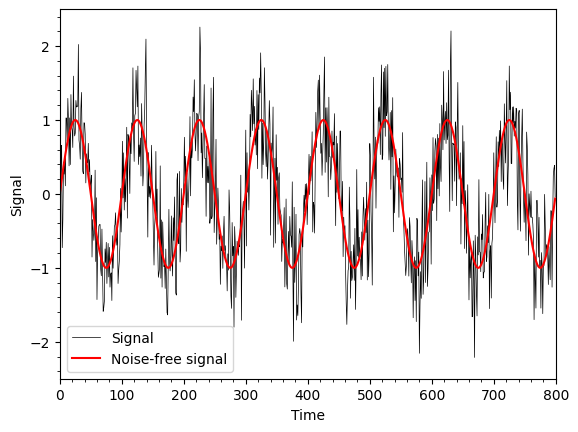

In [3]:
rng = np.random.default_rng(seed=42) #random number generator
t = np.arange(0,800,1) #create some time points
y = np.sin(2*np.pi*t/100) #sine wave
e = rng.standard_normal(800)*0.5 #random numbers to act as noise
signal = y+e #add the sine and noise to give a noisy signal

plt.plot(t,signal,'k',linewidth=0.5,label='Signal') #plot the noisy signal
plt.plot(t,y,'r',label='Noise-free signal') #plot the original sine wave
plt.xlim([0,800]) #limit the x-axis
plt.ylim([-2.5,2.5]) #limit the y-axis
plt.xlabel('Time') #label the x-axis
plt.ylabel('Signal') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks

The ```moving_average``` function can now be used to smooth the data.

Try moving averages with different lengths and see if you can recover the original sine from the noise.

Note that we process both the signal and the times so that we have corresponding points for plotting.

In [11]:
w = 15 #length of the moving average
ys = moving_average(signal, w) #process the signal
ts = moving_average(t, w) #process the times

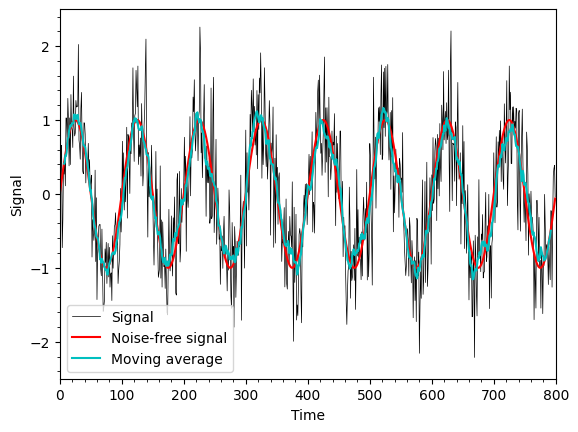

In [12]:
plt.plot(t,signal,'k',linewidth=0.5,label='Signal') #plot the noisy signal
plt.plot(t,y,'r',label='Noise-free signal') #plot the original sine wave
plt.plot(ts,ys,'c',label='Moving average') #plot the moving average
plt.xlim([0,800]) #limit the x-axis
plt.ylim([-2.5,2.5]) #limit the y-axis
plt.xlabel('Time') #label the x-axis
plt.ylabel('Signal') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks